
# Lithium atomic beam: transverse cooling + optional 2D MOT + downstream orifice optimization

This notebook adds:

**(i)** Side-view schematic plots (x vs z) with representative trajectories for three cases:
1. No cooling, no 2D MOT
2. Transverse cooling in mirror region only
3. Transverse cooling + optimized 2D MOT just behind the mirrors

**(ii)** Prints the **optimized 2D MOT parameters** (length + spring/damping) and the achieved gain in flux through the downstream orifice.

## Notes
- Physics is a **fast design-level model** (two-level Doppler molasses in the mirror region, and a linear spring+damping model for the 2D MOT).
- The 2D MOT model captures the “focusing + damping” effect:
  \[ \mathbf F_\perp = -\kappa \mathbf r_\perp - \beta \mathbf v_\perp. \]
- The downstream orifice is a **1 cm diameter** aperture located **50 cm after the mirror end**, as requested.

- Updated propagation now uses each atom's own longitudinal velocity through the mirror and 2D-MOT regions, fixes the downstream drift geometry, and records several intermediate trajectory points so the side-view is more physical.


In [1]:
# Enable automatic reloading of modules so that changes in external Python files are reflected without restarting the notebook
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from dataclasses import dataclass, replace
from scipy.constants import k as k_B, h, c, atomic_mass
from scipy.special import erf
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
import li6_cooling_opt_functions as cool
import ipywidgets as widgets

rng = np.random.default_rng(12345)

# ---------------- Physical constants ----------------
h = 6.62607015e-34
hbar = h/(2*np.pi)
kB = 1.380649e-23
amu = 1.66053906660e-27

print("Imports and constants loaded.")

Imports and constants loaded.


In [3]:
%matplotlib widget


## User parameters (edit here)


In [34]:
cfg = cool.SourceConfig(tube_length=0.1, tube_radius=0.007/2)
# cfg = cool.SourceConfig()
print(f"SourceConfig created: {cfg}")

SourceConfig created: SourceConfig(N_atoms=5000000, isotope='Li-6', mass=9.988142485598999e-27, lambda0=6.70977e-07, k=9364233.50901683, Gamma=36882297.753144175, Isat_mW_cm2=2.54, Isat=25.4, T_oven_C=600.0, T_oven_K=873.15, oven_channel_radius=0.02, tube_length=0.1, tube_radius=0.0035, beta_mot=0.0, kappa_mot=0.0, length_mot=0.05, N_bounce_x=6, N_bounce_y=6, Rpass_x=0.9, Rpass_y=0.9, length_mirror=0.2, Px_mW=80.0, Py_mW=80.0, w_mm=6.0, delta_over_Gamma=-1.0, z_cooling_start=0.02, z_cooling_end=0.22, z_mot_start=0.23, z_mot_end=0.28, z_orifice=3.0, orifice_radius=0.005, use_skimmer=False, skimmer_radius=0.005, dt=2e-06, include_diffusion=True, alpha_diff=0.5)



## Effusive flux estimate (order-of-magnitude)


In [35]:
Ndot_hole, P_oven, n_oven, vbar, A_hole = cool.effusive_flux_atoms_per_s(cfg.T_oven_K, cfg.mass, cfg.oven_channel_radius*2)
print(f"Vapor pressure ~ {P_oven:.3g} Pa, mean speed ~ {vbar:.1f} m/s")
print(f"Flux through the oven channel (prior to tube exit) ~ {Ndot_hole:.3e} atoms/s")

Vapor pressure ~ 6.59 Pa, mean speed ~ 1753.1 m/s
Flux through the oven channel (prior to tube exit) ~ 3.011e+20 atoms/s



## Mirror-pass gain and Doppler molasses model


In [36]:
# Effective saturation inside mirror region
w_m = cfg.w_mm*1e-3
I0x = cool.gaussian_I0(cfg.Px_mW*1e-3, w_m)
I0y = cool.gaussian_I0(cfg.Py_mW*1e-3, w_m)
s0x = I0x/cfg.Isat
s0y = I0y/cfg.Isat

Gx = cool.gain_geometric(cfg.N_bounce_x, cfg.Rpass_x)
Gy = cool.gain_geometric(cfg.N_bounce_y, cfg.Rpass_y)

s0x_eff = Gx*s0x
s0y_eff = Gy*s0y

print(f"Gx={Gx:.2f}, Gy={Gy:.2f}")
print(f"s0x_eff={s0x_eff:.2f}, s0y_eff={s0y_eff:.2f}")


Gx=4.69, Gy=4.69
s0x_eff=260.97, s0y_eff=260.97



## Efficient effusive sampling with optional skimmer at z_start


Sampled atoms: 6155
Transmission frequency: 0.12310000000000001 %
Mean vz: 2054.9319187250694
Mean transverse speed: 65.28595077982548
Oven consumption rate: 9.795e-03 grams/day
Oven consumption rate: 4.081e-04 grams/hour
Oven consumption rate: 3.578e+00 grams/year


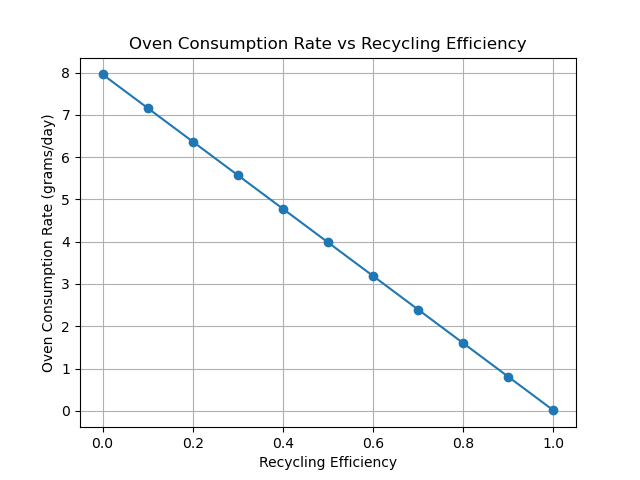

In [38]:
# This creates the distribution of atoms exiting the tube, including their positions and velocities, to use in the cooling and MOT sims
beam_exiting_tube = cool.sample_effusive_beam(cfg)
print("Sampled atoms:", len(beam_exiting_tube["x"]))
print("Transmission frequency:", len(beam_exiting_tube["x"])/cfg.N_atoms * 100, "%")
print("Mean vz:", beam_exiting_tube["vz"].mean())
print("Mean transverse speed:", np.sqrt(beam_exiting_tube["vx"]**2 + beam_exiting_tube["vy"]**2).mean())

# Calculate the oven consumption
consumption_rates = cool.oven_consumption_rate(beam_exiting_tube, cfg, recycling_efficiency=1.0)
print(f"Oven consumption rate: {consumption_rates['consumption_rate_grams_per_day']:.3e} grams/day")
print(f"Oven consumption rate: {consumption_rates['consumption_rate_grams_per_hour']:.3e} grams/hour")
print(f"Oven consumption rate: {consumption_rates['consumption_rate_grams_per_year']:.3e} grams/year")

recycling_efficiencies = np.linspace(0, 1, 11)
cool.plot_consumptions(beam_exiting_tube, cfg, recycling_efficiencies=recycling_efficiencies)

In [8]:
test = 8.61e17 # atoms/s
# convert to grams/day
print(f"Test consumption rate: {test*cfg.mass*1e-3*86400:.3e} grams/day")

Test consumption rate: 7.430e-07 grams/day


## Model update notes

This version fixes three important issues in the original propagation:

1. Each atom now spends its **own** time in the mirror and 2D-MOT regions according to its own \(v_z\), rather than using the time of a very slow atom for everyone.
2. The drift to the downstream orifice now starts from the **actual end of the MOT section**.
3. The trajectory plot stores several intermediate points inside the mirror and MOT regions, so the side-view is no longer just a few straight segments between section boundaries.

The 2D MOT itself is still a **toy spring+damping model**,
\[
F_x=-\kappa x-eta v_x,\qquad F_y=-\kappa y-eta v_y,
\]
so the notebook should still be interpreted as a fast design study rather than a full lithium MOT simulation.

In [9]:
df_scan, best = cool.optimize_2dmot_with_beam(beam_exiting_tube, cfg)
best

{'L_mot_cm': 15.0,
 'beta': 5e-23,
 'kappa': 2e-19,
 'frac_pass': np.float64(0.41243862520458263),
 'Ndot_orifice': np.float64(756.0),
 'orifice_flux': np.float64(372025481981745.9)}

In [10]:
df_scan.sort_values("Ndot_orifice", ascending=False).head(10)

,L_mot_cm,beta,kappa,frac_pass,Ndot_orifice,orifice_flux
247,15.0,5.000000e-23,2.000000e-19,0.412439,756.0,3.720255e+14
175,10.0,5.000000e-23,2.000000e-19,0.386252,708.0,3.484048e+14
211,12.5,5.000000e-23,2.000000e-19,0.384615,705.0,3.469285e+14
246,15.0,5.000000e-23,0.000000e+00,0.369885,678.0,3.336419e+14
210,12.5,5.000000e-23,0.000000e+00,0.352428,646.0,3.178948e+14
139,7.5,5.000000e-23,2.000000e-19,0.336607,617.0,3.036240e+14
241,15.0,2.000000e-23,2.000000e-19,0.322968,592.0,2.913215e+14
205,12.5,2.000000e-23,2.000000e-19,0.320240,587.0,2.888611e+14
103,5.0,5.000000e-23,2.000000e-19,0.312057,572.0,2.814796e+14
169,10.0,2.000000e-23,2.000000e-19,0.305510,560.0,2.755744e+14


### Trajectory-plot fix
The side-view snapshots now interpolate each selected atom to common z-planes. This removes the old plotting artifact that could make straight drifts appear to bend or focus.



## Run three cases and plot side-view trajectories


In [11]:
# --- run the three configurations ---
n_traj = 200

# Case 1: no cooling, no 2D MOT
case1 = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg, beta_mot=0.0, kappa_mot=0.0),
    use_mot=False,
    mirror_cooling=False,
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

# Case 2: mirror cooling only, no 2D MOT
case2 = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg, beta_mot=0.0, kappa_mot=0.0),
    use_mot=False,
    mirror_cooling=True,
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

# Case 3: mirror cooling + 2D MOT
case3 = cool.propagate_system_with_beam(
    beam=beam_exiting_tube,
    cfg=replace(cfg, beta_mot=best["beta"], kappa_mot=best["kappa"]),
    use_mot=True,
    mirror_cooling=True,
    record_traj=True,
    n_traj=n_traj,
    n_record_region=6,
    orifice_reference="3 meters from tube exit"
)

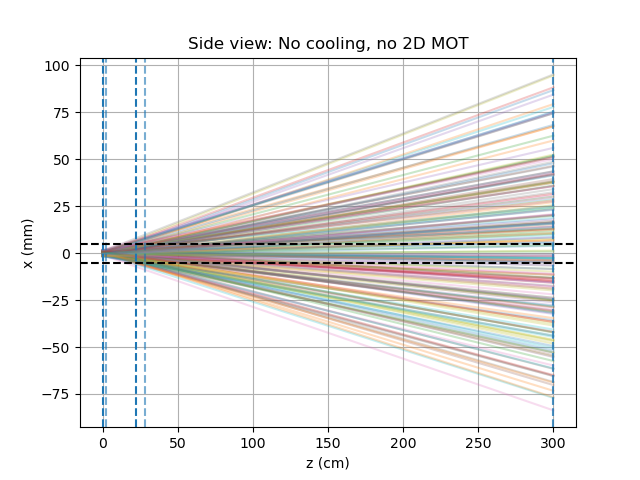

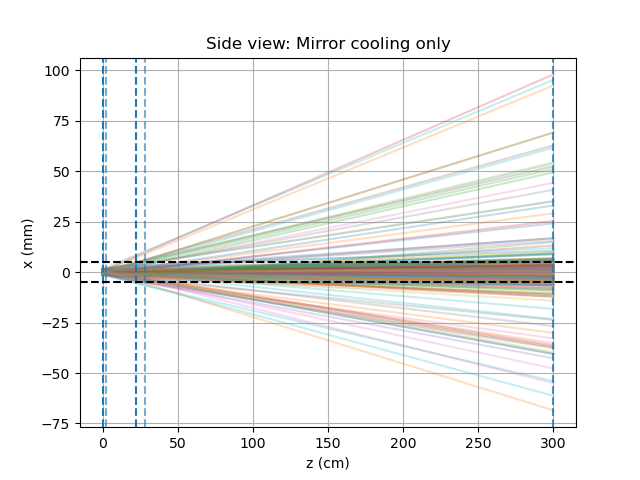

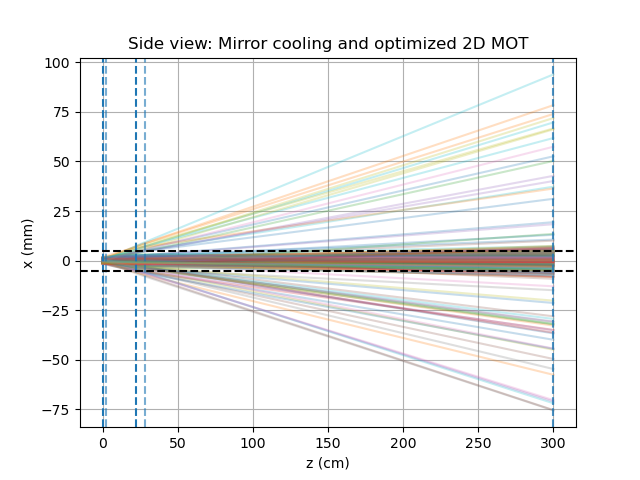

In [12]:
cases = ["No cooling, no 2D MOT", "Mirror cooling only", "Mirror cooling and optimized 2D MOT"]
for i in range(3):
    cool.plot_sideview(eval(f"case{i+1}"), cfg, f"Side view: {cases[i]}")



## Print optimized 2D MOT dimensions/parameters (requested)


In [ ]:
# --- compute gains ---

gain_cooling = case2["Ndot_orifice"] / case1["Ndot_orifice"]
gain_bestmot = case3["Ndot_orifice"] / case2["Ndot_orifice"]
gain_total   = case3["Ndot_orifice"] / case1["Ndot_orifice"]

print("---- Achieved fluxes ----")
print(f"No cooling/no MOT flux      : {case1['Ndot_orifice']:.3e} atoms/s")
print(f"Cooling only flux           : {case2['Ndot_orifice']:.3e} atoms/s  (gain {gain_cooling:.3f}×)")
print(f"Cooling + best 2D MOT flux  : {case3['Ndot_orifice']:.3e} atoms/s  (gain vs cooling {gain_bestmot:.3f}×, total {gain_total:.3f}×)")
print("==== OPTIMIZED 2D MOT DESIGN (coarse scan) ====")
print(f"L_mot_cm  = {best['L_mot_cm']}")
print(f"beta_mot  = {best['beta']:.3e}  kg/s")
print(f"kappa_mot = {best['kappa']:.3e} N/m")
print("---- Achieved fluxes ----")
print(f"No cooling/no MOT flux      : {case1['Ndot_orifice']:.3e} atoms/s")
print(f"Cooling only flux           : {case2['Ndot_orifice']:.3e} atoms/s  (gain {gain_cooling:.3f}×)")
print(f"Cooling + best 2D MOT flux  : {case3['Ndot_orifice']:.3e} atoms/s  (gain vs cooling {gain_bestmot:.3f}×, total {gain_total:.3f}×)")
